# Visualisasi Heatmap & Connectivity — GC dan PDC

Menghasilkan 4 jenis gambar per sesi per subjek:

| File | Isi |
|------|-----|
| `viz_gc_heatmap.png` | Heatmap GC rata-rata per emosi (3 panel) |
| `viz_gc_connectivity.png` | Circular connectivity diagram GC (3 emosi) |
| `viz_pdc_heatmap.png` | Heatmap PDC per band × 3 emosi |
| `viz_pdc_connectivity.png` | Circular connectivity PDC per band |

**Style**: Clean white background, standard matplotlib — seperti grafik publikasi ilmiah.

## Cell 1: Import

In [7]:
import numpy as np
import os
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import seaborn as sns

# Style: bersih, publikasi ilmiah
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 9,
    'axes.titlesize'   : 11,
    'axes.labelsize'   : 9,
    'axes.titleweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'figure.dpi'       : 120,
    'savefig.facecolor': 'white',
    'savefig.bbox'     : 'tight',
})

print('OK — matplotlib', matplotlib.__version__, '| seaborn', sns.__version__)

OK — matplotlib 3.10.7 | seaborn 0.13.2


## Cell 2: Konfigurasi

In [8]:
GC_DIR   = r"D:\Skripsi\new_data\01_granger_causality\output\gc_matrices"
PDC_DIR  = r"D:\Skripsi\new_data\02_pdc\output\pdc_matrices"
CHAN_FILE = r"D:\Skripsi\dataset\SEED\SEED\channel_62_pos.locs"

TRIAL_LABELS = [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1]
EMOTION_MAP  = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}

# Warna emosi — biru/hijau/merah standar matplotlib
EMOTION_COLORS = {'Negative': '#d62728', 'Neutral': '#1f77b4', 'Positive': '#2ca02c'}

PDC_BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma', 'broadband']
BAND_FREQ = {
    'delta': '0.5-4 Hz', 'theta': '4-8 Hz', 'alpha': '8-13 Hz',
    'beta' : '13-30 Hz', 'gamma': '30-45 Hz', 'broadband': '0.5-45 Hz',
}
# Warna band — tab10 matplotlib standar
BAND_COLORS = {
    'delta': '#9467bd', 'theta': '#1f77b4', 'alpha': '#2ca02c',
    'beta' : '#ff7f0e', 'gamma': '#d62728', 'broadband': '#7f7f7f',
}

CHANNEL_NAMES = [
    'Fp1','Fpz','Fp2','AF3','AF4','F7','F5','F3','F1','Fz',
    'F2','F4','F6','F8','FT7','FC5','FC3','FC1','FCz','FC2',
    'FC4','FC6','FT8','T7','C5','C3','C1','Cz','C2','C4',
    'C6','T8','TP7','CP5','CP3','CP1','CPz','CP2','CP4','CP6',
    'TP8','P7','P5','P3','P1','Pz','P2','P4','P6','P8',
    'PO7','PO5','PO3','POz','PO4','PO6','PO8','CB1','O1','Oz',
    'O2','CB2'
]
N_CH = len(CHANNEL_NAMES)  # 62

# Region untuk warna node
REGION_MAP = {
    'Prefrontal'    : ['Fp1','Fpz','Fp2','AF3','AF4'],
    'Frontal'       : ['F7','F5','F3','F1','Fz','F2','F4','F6','F8'],
    'Fronto-Central': ['FT7','FC5','FC3','FC1','FCz','FC2','FC4','FC6','FT8'],
    'Temporal'      : ['T7','C5','T8','TP7','TP8'],
    'Central'       : ['C3','C1','Cz','C2','C4','C6'],
    'Centro-Parietal': ['CP5','CP3','CP1','CPz','CP2','CP4','CP6'],
    'Parietal'      : ['P7','P5','P3','P1','Pz','P2','P4','P6','P8'],
    'Occipital'     : ['PO7','PO5','PO3','POz','PO4','PO6','PO8','CB1','O1','Oz','O2','CB2'],
}
# Warna region — tab10 matplotlib
REGION_COLORS = {
    'Prefrontal'    : '#d62728',
    'Frontal'       : '#ff7f0e',
    'Fronto-Central': '#bcbd22',
    'Temporal'      : '#2ca02c',
    'Central'       : '#17becf',
    'Centro-Parietal': '#1f77b4',
    'Parietal'      : '#9467bd',
    'Occipital'     : '#8c564b',
}

def get_region(ch):
    for r, chs in REGION_MAP.items():
        if ch in chs: return r
    return 'Central'

NODE_COLORS = [REGION_COLORS[get_region(ch)] for ch in CHANNEL_NAMES]

# Load channel positions
CHAN_XY = {}
try:
    with open(CHAN_FILE) as f:
        for line in f:
            p = line.strip().split()
            if len(p) >= 4:
                CHAN_XY[p[3].strip()] = (float(p[1]), float(p[2]))
    print(f'Channel positions: {len(CHAN_XY)} loaded')
except Exception as e:
    print(f'Channel file not found: {e}')

print(f'Config OK — {N_CH} channels, {len(PDC_BANDS)} bands')

Channel positions: 62 loaded
Config OK — 62 channels, 6 bands


## Cell 3: Fungsi Helper

In [9]:
def avg_by_emotion(sess_dir, prefix):
    """Rata-ratakan matriks .npy per emosi dari semua trial."""
    em = {'Negative': [], 'Neutral': [], 'Positive': []}
    for ti, label in enumerate(TRIAL_LABELS, 1):
        emotion = EMOTION_MAP[label]
        fp = os.path.join(sess_dir, f'{prefix}_trial_{ti:02d}.npy')
        if os.path.exists(fp):
            em[emotion].append(np.load(fp))
    return {e: np.mean(m, axis=0) if m else None for e, m in em.items()}


def get_circular_pos(n):
    """Koordinat melingkar untuk n node."""
    angles = np.linspace(np.pi/2, np.pi/2 + 2*np.pi, n, endpoint=False)
    return np.cos(angles), np.sin(angles)


print('Helper functions OK')

Helper functions OK


## Cell 4: Fungsi Visualisasi (Natural Style)

In [10]:
# ============================================================
# PLOT A: GC HEATMAP — clustered, 3 emosi side-by-side
# ============================================================

def plot_gc_heatmap(sess_dir, subj_id, sess_id, save_path):
    em_mats = avg_by_emotion(sess_dir, 'gc_thresholded')
    EMOTIONS = ['Negative', 'Neutral', 'Positive']

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        f'Granger Causality — {subj_id.replace("_"," ").title()} | {sess_id}',
        fontsize=13, fontweight='bold', y=1.01)

    for ax, emotion in zip(axes, EMOTIONS):
        mat = em_mats.get(emotion)
        if mat is None:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes)
            ax.set_title(emotion)
            continue

        # Reorder via hierarchical clustering
        mat_sym = (mat + mat.T) / 2
        np.fill_diagonal(mat_sym, 0)
        try:
            dist = squareform(np.clip(1 - mat_sym / (mat_sym.max() + 1e-10), 0, None))
            Z    = linkage(dist, method='ward')
            order = dendrogram(Z, no_plot=True)['leaves']
        except:
            order = list(range(N_CH))

        mat_r  = mat[np.ix_(order, order)]
        labels = [CHANNEL_NAMES[i] for i in order]

        # Heatmap dengan seaborn (white background, standard colormap)
        tick_step = 5
        ticks = list(range(0, N_CH, tick_step))
        tick_labels = [labels[i] for i in ticks]

        im = ax.imshow(mat_r, cmap='YlOrRd', aspect='auto',
                       interpolation='nearest')

        ax.set_xticks(ticks)
        ax.set_xticklabels(tick_labels, rotation=90, fontsize=6.5)
        ax.set_yticks(ticks)
        ax.set_yticklabels(tick_labels, fontsize=6.5)

        cbar = plt.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
        cbar.set_label('GC F-statistic', fontsize=8)
        cbar.ax.tick_params(labelsize=7)

        # Statistik di judul
        n_edges = np.count_nonzero(mat_r)
        density = n_edges / (N_CH * (N_CH - 1))
        mean_gc = mat_r[mat_r > 0].mean() if n_edges > 0 else 0

        ax.set_title(
            f'{emotion}\ndensity={density:.3f}, mean={mean_gc:.1f}, n={n_edges}',
            color=EMOTION_COLORS[emotion], fontsize=10, fontweight='bold')
        ax.set_xlabel('Channel (source)', fontsize=8)
        ax.set_ylabel('Channel (target)', fontsize=8)

        # Garis tepi berwarna sesuai emosi
        for spine in ax.spines.values():
            spine.set_edgecolor(EMOTION_COLORS[emotion])
            spine.set_linewidth(1.5)
            spine.set_visible(True)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close(fig)


# ============================================================
# PLOT B: GC CIRCULAR CONNECTIVITY
# ============================================================

def plot_gc_connectivity(sess_dir, subj_id, sess_id, save_path, top_pct=0.05):
    em_mats  = avg_by_emotion(sess_dir, 'gc_thresholded')
    EMOTIONS = ['Negative', 'Neutral', 'Positive']
    cx, cy   = get_circular_pos(N_CH)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        f'GC Connectivity — {subj_id.replace("_"," ").title()} | {sess_id}',
        fontsize=13, fontweight='bold', y=1.01)

    for ax, emotion in zip(axes, EMOTIONS):
        ax.set_aspect('equal')
        ax.axis('off')
        mat = em_mats.get(emotion)

        if mat is None:
            ax.set_title(emotion + '\nNo data')
            continue

        # Threshold: top 5%
        vals = mat[mat > 0]
        thr  = np.percentile(vals, (1 - top_pct) * 100) if len(vals) > 0 else 0
        strong = np.where(mat >= thr, mat, 0)
        max_v  = strong.max() if strong.max() > 0 else 1

        # Gambar edges
        em_color = EMOTION_COLORS[emotion]
        for i in range(N_CH):
            for j in range(N_CH):
                v = strong[i, j]
                if i == j or v == 0: continue
                alpha = 0.05 + 0.55 * (v / max_v)
                lw    = 0.2  + 1.8  * (v / max_v)
                ax.plot([cx[j], cx[i]], [cy[j], cy[i]],
                        color=em_color, alpha=alpha, lw=lw,
                        solid_capstyle='round', zorder=1)

        # Gambar nodes
        for i, (x, y, ch) in enumerate(zip(cx, cy, CHANNEL_NAMES)):
            deg  = np.count_nonzero(strong[i,:]) + np.count_nonzero(strong[:,i])
            size = max(15, 8 + deg * 2.5)
            ax.scatter(x, y, s=size, c=NODE_COLORS[i],
                       edgecolors='black', linewidths=0.4, zorder=5)
            # Label setiap 4 node
            if i % 4 == 0:
                r = 1.13
                ax.text(x * r, y * r, ch,
                        ha='center', va='center',
                        fontsize=5.5, color='black')

        # Region legend (hanya di panel pertama)
        if emotion == 'Negative':
            handles = [mpatches.Patch(color=c, label=r)
                       for r, c in REGION_COLORS.items()]
            ax.legend(handles=handles, loc='lower left',
                      fontsize=5.5, framealpha=0.8,
                      ncol=2, title='Brain Region', title_fontsize=6)

        n_edges = np.count_nonzero(strong)
        density = n_edges / (N_CH * (N_CH - 1))
        ax.set_title(
            f'{emotion}\ntop {int(top_pct*100)}% | {n_edges} edges | density={density:.3f}',
            color=EMOTION_COLORS[emotion], fontsize=10, fontweight='bold')
        ax.set_xlim(-1.3, 1.3)
        ax.set_ylim(-1.3, 1.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close(fig)


# ============================================================
# PLOT C: PDC HEATMAP — 6 band × 3 emosi
# ============================================================

def plot_pdc_heatmap(sess_dir, subj_id, sess_id, save_path):
    EMOTIONS = ['Negative', 'Neutral', 'Positive']

    fig, axes = plt.subplots(len(PDC_BANDS), 3,
                              figsize=(15, len(PDC_BANDS) * 2.8))
    fig.suptitle(
        f'PDC Heatmap — {subj_id.replace("_"," ").title()} | {sess_id}\n'
        f'Baris: Frequency Band | Kolom: Emotion',
        fontsize=12, fontweight='bold')

    for row, band in enumerate(PDC_BANDS):
        em_mats = avg_by_emotion(sess_dir, f'pdc_{band}')

        # vmax global per band
        all_v = [m for m in em_mats.values() if m is not None]
        vmax  = max(m.max() for m in all_v) if all_v else 1.0

        for col, emotion in enumerate(EMOTIONS):
            ax  = axes[row, col]
            mat = em_mats.get(emotion)

            if mat is None:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=ax.transAxes)
                ax.axis('off')
                continue

            im = ax.imshow(mat, cmap='Blues', aspect='auto',
                           vmin=0, vmax=vmax, interpolation='nearest')

            # Tick labels minimal
            step = max(1, N_CH // 8)
            ticks = list(range(0, N_CH, step))
            ax.set_xticks(ticks)
            ax.set_xticklabels(
                [CHANNEL_NAMES[t] for t in ticks],
                rotation=90, fontsize=5.5)
            ax.set_yticks(ticks)
            ax.set_yticklabels(
                [CHANNEL_NAMES[t] for t in ticks], fontsize=5.5)

            # Colorbar hanya kolom kanan
            if col == 2:
                cbar = plt.colorbar(im, ax=ax, shrink=0.9, pad=0.03)
                cbar.set_label('PDC', fontsize=7)
                cbar.ax.tick_params(labelsize=6)

            # Judul baris pertama: tampilkan emosi
            if row == 0:
                ax.set_title(
                    f'{emotion}\n{band.title()} ({BAND_FREQ[band]})',
                    color=EMOTION_COLORS[emotion], fontsize=9, fontweight='bold')
            else:
                ax.set_title(
                    f'{band.title()} ({BAND_FREQ[band]})',
                    color=BAND_COLORS[band], fontsize=9)

            # Stats
            mean_v = mat.mean()
            ax.text(0.97, 0.03,
                    f'mean={mean_v:.3f}',
                    transform=ax.transAxes, fontsize=6,
                    ha='right', va='bottom',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white',
                              alpha=0.7, ec='gray', lw=0.5))

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(save_path, dpi=130)
    plt.close(fig)


# ============================================================
# PLOT D: PDC CIRCULAR CONNECTIVITY — 6 band × 3 emosi
# ============================================================

def plot_pdc_connectivity(sess_dir, subj_id, sess_id, save_path, top_pct=0.08):
    EMOTIONS = ['Negative', 'Neutral', 'Positive']
    cx, cy   = get_circular_pos(N_CH)

    fig, axes = plt.subplots(len(PDC_BANDS), 3,
                              figsize=(14, len(PDC_BANDS) * 2.8))
    fig.suptitle(
        f'PDC Connectivity — {subj_id.replace("_"," ").title()} | {sess_id}',
        fontsize=12, fontweight='bold')

    for row, band in enumerate(PDC_BANDS):
        em_mats    = avg_by_emotion(sess_dir, f'pdc_{band}')
        band_color = BAND_COLORS[band]

        for col, emotion in enumerate(EMOTIONS):
            ax  = axes[row, col]
            ax.set_aspect('equal')
            ax.axis('off')
            mat = em_mats.get(emotion)

            if mat is None:
                ax.set_title(f'{band}\nNo data', fontsize=7)
                continue

            # Threshold top 8%
            thr   = np.percentile(mat.flatten(), (1 - top_pct) * 100)
            strong = np.where(mat >= thr, mat, 0)
            max_v  = strong.max() if strong.max() > 0 else 1

            em_color = EMOTION_COLORS[emotion]

            # Edges
            for i in range(N_CH):
                for j in range(N_CH):
                    v = strong[i, j]
                    if i == j or v == 0: continue
                    strength = v / max_v
                    alpha = 0.04 + 0.5 * strength
                    lw    = 0.1 + 1.5 * strength
                    ax.plot([cx[j], cx[i]], [cy[j], cy[i]],
                            color=band_color, alpha=alpha, lw=lw,
                            solid_capstyle='round', zorder=1)

            # Nodes
            for i, (x, y, ch) in enumerate(zip(cx, cy, CHANNEL_NAMES)):
                deg  = np.count_nonzero(strong[i,:]) + np.count_nonzero(strong[:,i])
                size = max(8, 5 + deg * 2)
                ax.scatter(x, y, s=size, c=NODE_COLORS[i],
                           edgecolors='black', linewidths=0.3, zorder=5)
                if i % 8 == 0:
                    ax.text(x*1.14, y*1.14, ch,
                            ha='center', va='center',
                            fontsize=4.5, color='black')

            n_edges = np.count_nonzero(strong)
            density = n_edges / (N_CH * (N_CH - 1))

            # Judul
            if row == 0:
                ax.set_title(
                    f'{emotion}\n{band.title()} | d={density:.3f}',
                    color=EMOTION_COLORS[emotion], fontsize=8, fontweight='bold')
            else:
                ax.set_title(
                    f'{band.title()} | d={density:.3f}',
                    color=band_color, fontsize=8)

            ax.set_xlim(-1.3, 1.3)
            ax.set_ylim(-1.3, 1.3)

    # Legend region di luar grid
    region_handles = [
        mpatches.Patch(color=c, label=r)
        for r, c in REGION_COLORS.items()
    ]
    fig.legend(handles=region_handles, loc='lower center', ncol=4,
               fontsize=7, framealpha=0.9, title='Brain Region',
               title_fontsize=7, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout(rect=[0, 0.04, 1, 0.97])
    plt.savefig(save_path, dpi=120)
    plt.close(fig)


print('Semua fungsi visualisasi siap ✅')

Semua fungsi visualisasi siap ✅


## Cell 5: Audit — Cek yang Belum Ada

In [11]:
gc_todo  = []
pdc_todo = []

print('=' * 60)
print('  AUDIT — Sesi yang perlu divisualisasi')
print('=' * 60)

for subj_dir in sorted(os.listdir(GC_DIR)):
    sp = os.path.join(GC_DIR, subj_dir)
    if not os.path.isdir(sp): continue
    for sess_dir in sorted(os.listdir(sp)):
        sess_path = os.path.join(sp, sess_dir)
        if not os.path.isdir(sess_path): continue
        hm = os.path.exists(os.path.join(sess_path, 'viz_gc_heatmap.png'))
        cn = os.path.exists(os.path.join(sess_path, 'viz_gc_connectivity.png'))
        if not hm or not cn:
            gc_todo.append((subj_dir, sess_dir, sess_path))
            print(f'  GC  {subj_dir}/{sess_dir}: '
                  f'[HM:{"✅" if hm else "❌"} CN:{"✅" if cn else "❌"}]')

for subj_dir in sorted(os.listdir(PDC_DIR)):
    sp = os.path.join(PDC_DIR, subj_dir)
    if not os.path.isdir(sp): continue
    for sess_dir in sorted(os.listdir(sp)):
        sess_path = os.path.join(sp, sess_dir)
        if not os.path.isdir(sess_path): continue
        hm = os.path.exists(os.path.join(sess_path, 'viz_pdc_heatmap.png'))
        cn = os.path.exists(os.path.join(sess_path, 'viz_pdc_connectivity.png'))
        if not hm or not cn:
            pdc_todo.append((subj_dir, sess_dir, sess_path))
            print(f'  PDC {subj_dir}/{sess_dir}: '
                  f'[HM:{"✅" if hm else "❌"} CN:{"✅" if cn else "❌"}]')

print()
print(f'GC  todo: {len(gc_todo)} sesi x 2 gambar = {len(gc_todo)*2} gambar')
print(f'PDC todo: {len(pdc_todo)} sesi x 2 gambar = {len(pdc_todo)*2} gambar')
total = (len(gc_todo) + len(pdc_todo)) * 2
est   = total * 10
print(f'Total   : {total} gambar | estimasi ~{est//60} menit')

  AUDIT — Sesi yang perlu divisualisasi
  PDC subject_03/session_20140629: [HM:✅ CN:❌]
  PDC subject_04/session_20140621: [HM:❌ CN:❌]
  PDC subject_04/session_20140702: [HM:❌ CN:❌]
  PDC subject_04/session_20140705: [HM:❌ CN:❌]
  PDC subject_05/session_20140411: [HM:❌ CN:❌]
  PDC subject_05/session_20140418: [HM:❌ CN:❌]
  PDC subject_05/session_20140506: [HM:❌ CN:❌]
  PDC subject_06/session_20130712: [HM:❌ CN:❌]
  PDC subject_06/session_20131016: [HM:❌ CN:❌]
  PDC subject_06/session_20131113: [HM:❌ CN:❌]
  PDC subject_07/session_20131027: [HM:❌ CN:❌]
  PDC subject_07/session_20131030: [HM:❌ CN:❌]
  PDC subject_07/session_20131106: [HM:❌ CN:❌]
  PDC subject_08/session_20140511: [HM:❌ CN:❌]
  PDC subject_08/session_20140514: [HM:❌ CN:❌]
  PDC subject_08/session_20140521: [HM:❌ CN:❌]
  PDC subject_09/session_20140620: [HM:❌ CN:❌]
  PDC subject_09/session_20140627: [HM:❌ CN:❌]
  PDC subject_09/session_20140704: [HM:❌ CN:❌]
  PDC subject_10/session_20131130: [HM:❌ CN:❌]
  PDC subject_10/ses

## Cell 6: Generate GC

In [12]:
print(f'Generate GC visualizations ({len(gc_todo)} sesi)...')
print('-' * 55)

ok = err = skip = 0
t0_all = time.time()

for idx, (subj_dir, sess_dir, sess_path) in enumerate(gc_todo, 1):
    hm_path = os.path.join(sess_path, 'viz_gc_heatmap.png')
    cn_path = os.path.join(sess_path, 'viz_gc_connectivity.png')
    print(f'  [{idx:2d}/{len(gc_todo)}] {subj_dir}/{sess_dir}', end=' ')
    t0 = time.time()
    try:
        if not os.path.exists(hm_path):
            plot_gc_heatmap(sess_path, subj_dir, sess_dir, hm_path)
        if not os.path.exists(cn_path):
            plot_gc_connectivity(sess_path, subj_dir, sess_dir, cn_path)
        ok += 1
        print(f'✅ {time.time()-t0:.1f}s')
    except Exception as e:
        err += 1
        print(f'❌ {str(e)[:70]}')

print(f'\nGC selesai: {ok} OK | {err} error | {(time.time()-t0_all)/60:.1f} menit')

Generate GC visualizations (0 sesi)...
-------------------------------------------------------

GC selesai: 0 OK | 0 error | 0.0 menit


## Cell 7: Generate PDC

In [13]:
print(f'Generate PDC visualizations ({len(pdc_todo)} sesi)...')
print('-' * 55)

ok = err = 0
t0_all = time.time()

for idx, (subj_dir, sess_dir, sess_path) in enumerate(pdc_todo, 1):
    hm_path = os.path.join(sess_path, 'viz_pdc_heatmap.png')
    cn_path = os.path.join(sess_path, 'viz_pdc_connectivity.png')
    print(f'  [{idx:2d}/{len(pdc_todo)}] {subj_dir}/{sess_dir}', end=' ')
    t0 = time.time()
    try:
        if not os.path.exists(hm_path):
            plot_pdc_heatmap(sess_path, subj_dir, sess_dir, hm_path)
        if not os.path.exists(cn_path):
            plot_pdc_connectivity(sess_path, subj_dir, sess_dir, cn_path)
        ok += 1
        print(f'✅ {time.time()-t0:.1f}s')
    except Exception as e:
        err += 1
        print(f'❌ {str(e)[:70]}')

print(f'\nPDC selesai: {ok} OK | {err} error | {(time.time()-t0_all)/60:.1f} menit')

Generate PDC visualizations (37 sesi)...
-------------------------------------------------------
  [ 1/37] subject_03/session_20140629 ✅ 13.8s
  [ 2/37] subject_04/session_20140621 ✅ 13.9s
  [ 3/37] subject_04/session_20140702 ✅ 14.8s
  [ 4/37] subject_04/session_20140705 ✅ 14.0s
  [ 5/37] subject_05/session_20140411 ✅ 14.2s
  [ 6/37] subject_05/session_20140418 ✅ 14.3s
  [ 7/37] subject_05/session_20140506 ✅ 14.3s
  [ 8/37] subject_06/session_20130712 ✅ 14.5s
  [ 9/37] subject_06/session_20131016 ✅ 13.9s
  [10/37] subject_06/session_20131113 ✅ 15.8s
  [11/37] subject_07/session_20131027 ✅ 14.6s
  [12/37] subject_07/session_20131030 ✅ 14.0s
  [13/37] subject_07/session_20131106 ✅ 14.5s
  [14/37] subject_08/session_20140511 ✅ 14.2s
  [15/37] subject_08/session_20140514 ✅ 14.2s
  [16/37] subject_08/session_20140521 ✅ 14.3s
  [17/37] subject_09/session_20140620 ✅ 14.4s
  [18/37] subject_09/session_20140627 ✅ 15.7s
  [19/37] subject_09/session_20140704 ✅ 14.5s
  [20/37] subject_10/session_

## Cell 8: Verifikasi & Preview

GC  gambar: 86  (target: 84=84)
PDC gambar: 90 (target: 90=90)


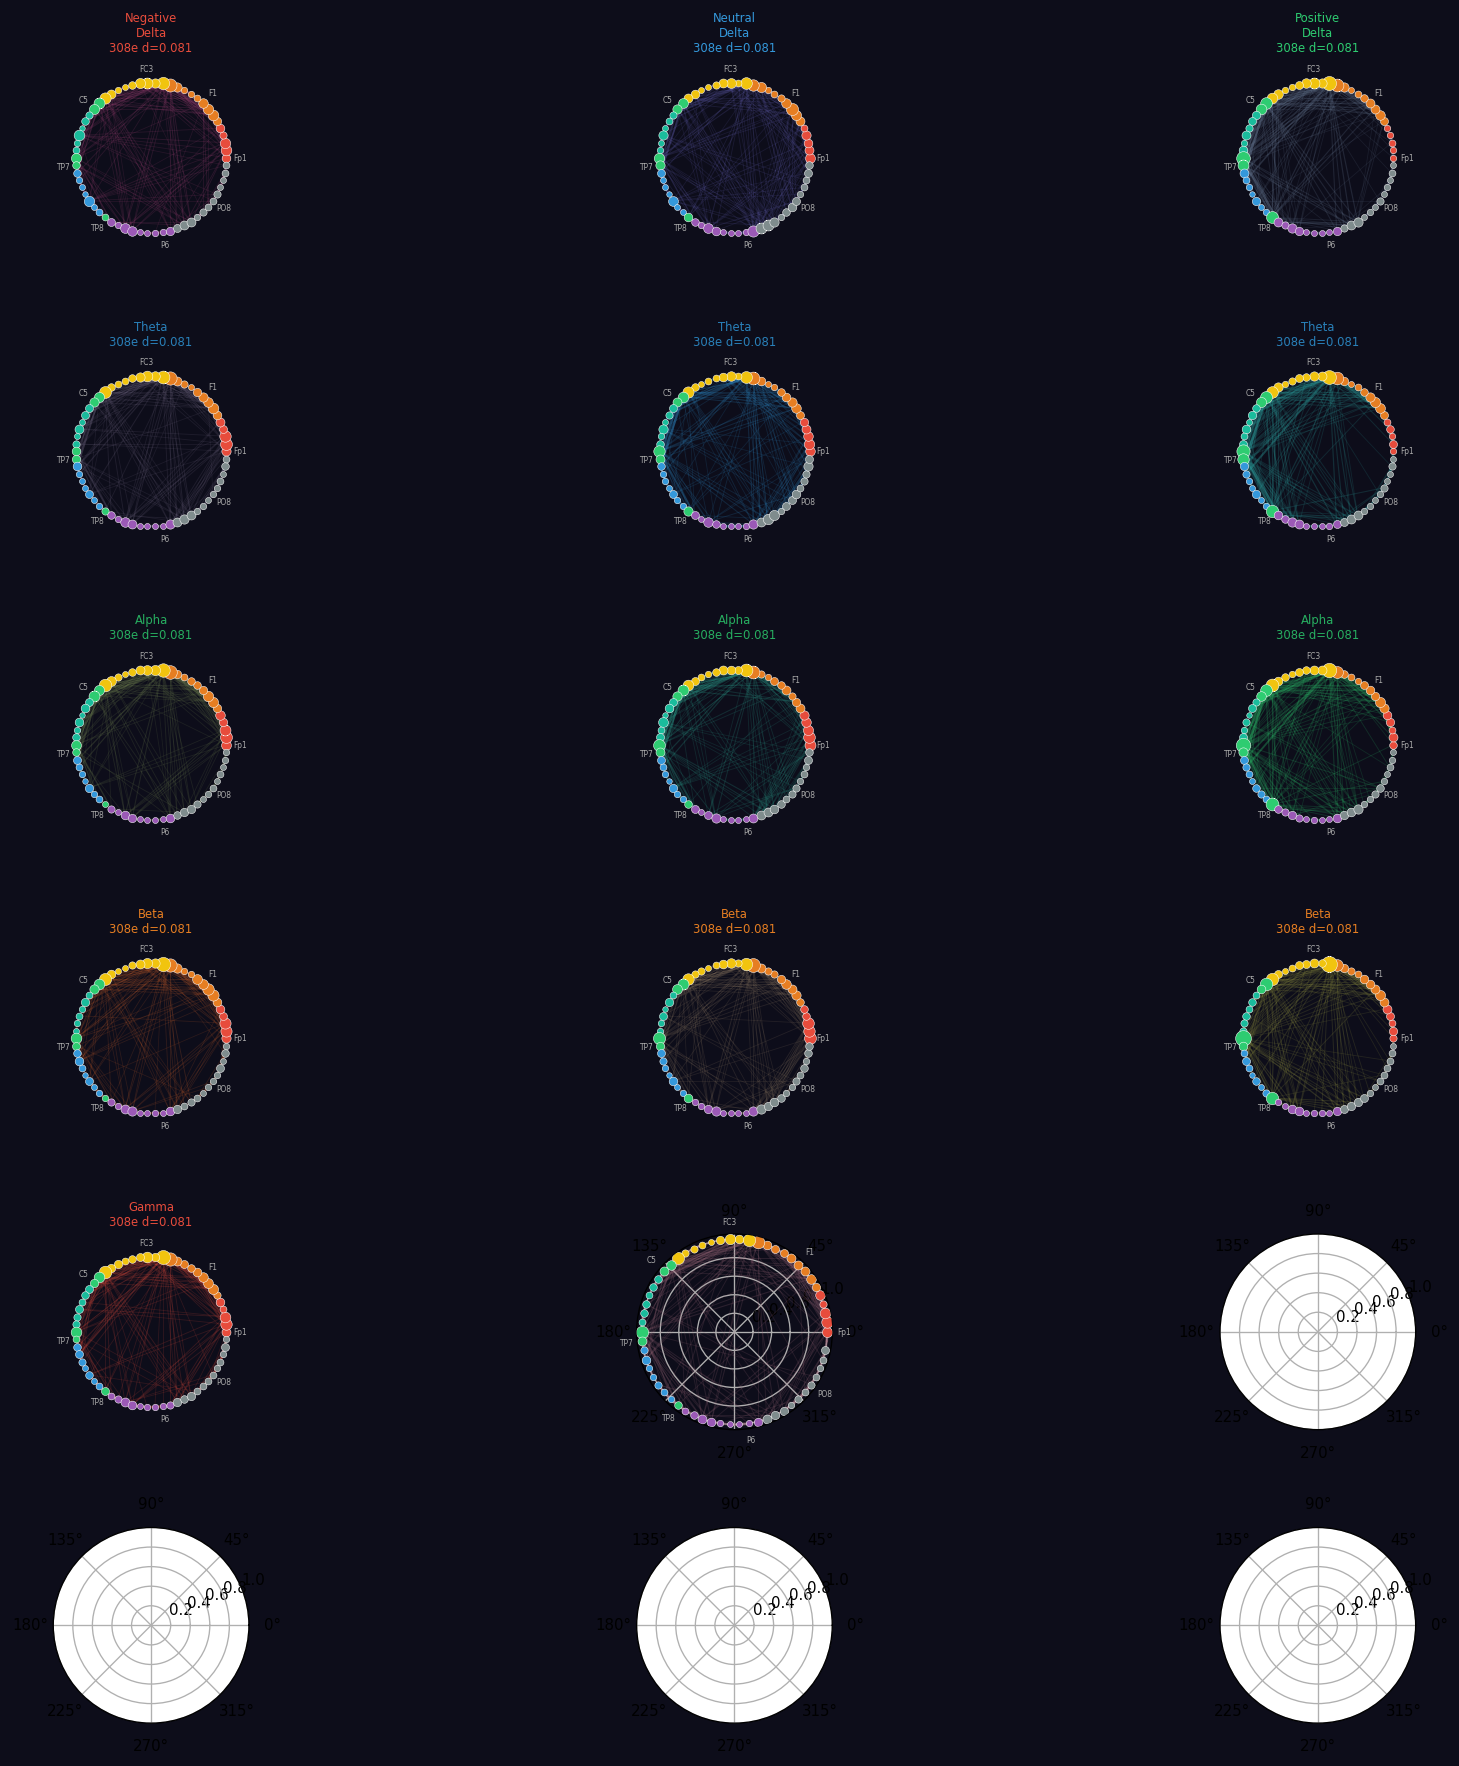

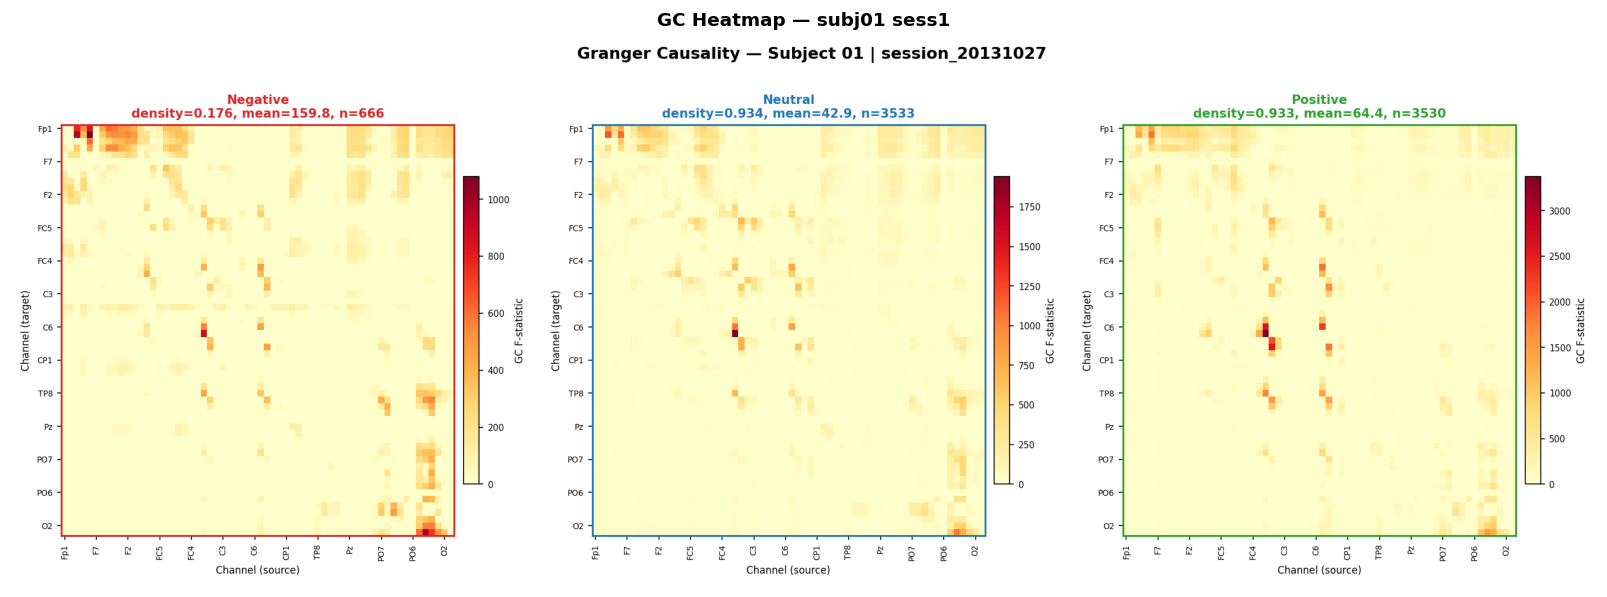

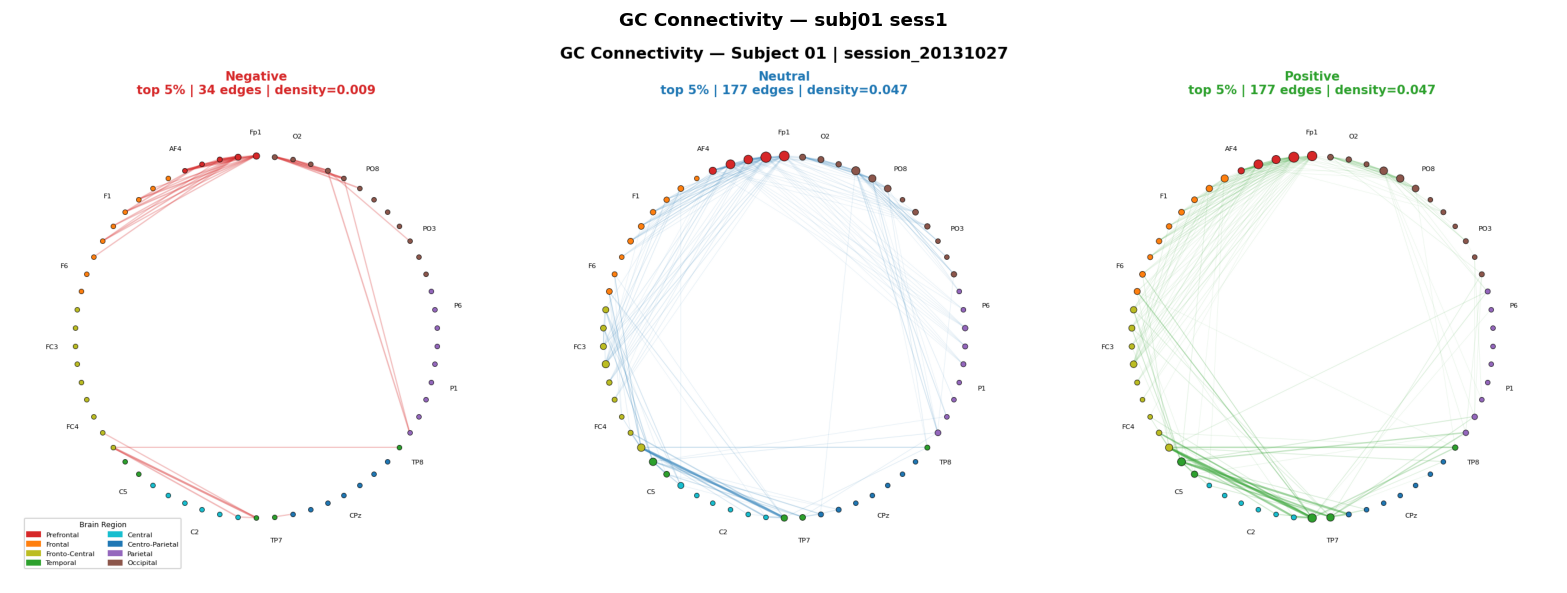

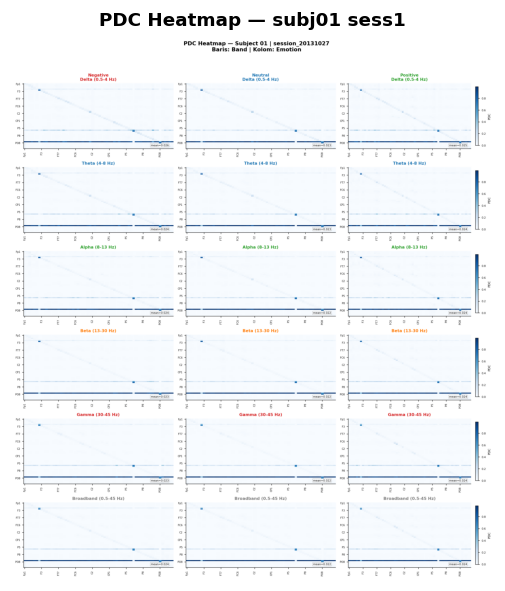

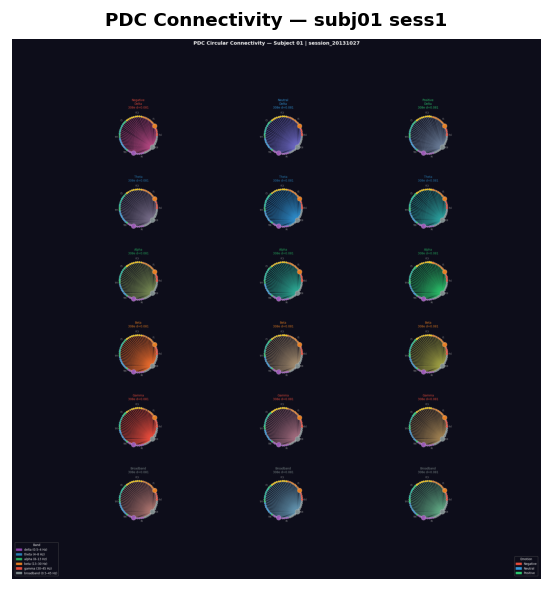

In [14]:
# Switch ke inline untuk tampil di notebook
%matplotlib inline

gc_imgs = pdc_imgs = 0
for subj_dir in sorted(os.listdir(GC_DIR)):
    sp = os.path.join(GC_DIR, subj_dir)
    if not os.path.isdir(sp): continue
    for sess_dir in sorted(os.listdir(sp)):
        d = os.path.join(sp, sess_dir)
        if not os.path.isdir(d): continue
        if os.path.exists(os.path.join(d, 'viz_gc_heatmap.png')): gc_imgs += 1
        if os.path.exists(os.path.join(d, 'viz_gc_connectivity.png')): gc_imgs += 1

for subj_dir in sorted(os.listdir(PDC_DIR)):
    sp = os.path.join(PDC_DIR, subj_dir)
    if not os.path.isdir(sp): continue
    for sess_dir in sorted(os.listdir(sp)):
        d = os.path.join(sp, sess_dir)
        if not os.path.isdir(d): continue
        if os.path.exists(os.path.join(d, 'viz_pdc_heatmap.png')): pdc_imgs += 1
        if os.path.exists(os.path.join(d, 'viz_pdc_connectivity.png')): pdc_imgs += 1

print(f'GC  gambar: {gc_imgs}  (target: {14*3*2}=84)')
print(f'PDC gambar: {pdc_imgs} (target: {15*3*2}=90)')

# Preview 4 gambar sampel
samples = [
    ('GC Heatmap — subj01 sess1',
     os.path.join(GC_DIR,'subject_01','session_20131027','viz_gc_heatmap.png')),
    ('GC Connectivity — subj01 sess1',
     os.path.join(GC_DIR,'subject_01','session_20131027','viz_gc_connectivity.png')),
    ('PDC Heatmap — subj01 sess1',
     os.path.join(PDC_DIR,'subject_01','session_20131027','viz_pdc_heatmap.png')),
    ('PDC Connectivity — subj01 sess1',
     os.path.join(PDC_DIR,'subject_01','session_20131027','viz_pdc_connectivity.png')),
]

for title, path in samples:
    if os.path.exists(path):
        img = plt.imread(path)
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title, fontsize=11, pad=8)
        plt.tight_layout()
        plt.show()
    else:
        print(f'  ⚠️  Tidak ditemukan: {os.path.basename(path)}')